# AI Crypto Hedge Fund

## Level 1. Baseline strategy on a single pair (BTC/USDT)

This notebook is a "showcase": it imports the logic from the `chf` package (the `src/chf` folder) and presents the results. Here we implement a **baseline strategy** based on a moving-average crossover and evaluate it on return and risk metrics.

This is the *baseline* that the smarter agents in the following levels are expected to beat.

## Setup
Import the libraries and our `chf` package.

In [1]:
import sys
sys.path.insert(0, "src")  # so the notebook can see the chf package in src/

import matplotlib.pyplot as plt
import pandas as pd

from chf.data.loader import load_ohlcv
from chf.strategies.moving_average import MovingAverageCross
from chf.services.backtest import run_backtest
from chf.services import metrics as M

print("Libraries loaded.")

Libraries loaded.


## 1. Load the data
We use daily BTC/USDT candles downloaded by the `scripts/download_data.py` script.

In [2]:
btc = load_ohlcv("BTC/USDT")
print(f"{len(btc)} rows, period from {btc.index.min().date()} to {btc.index.max().date()}")
btc[["open", "high", "low", "close", "volume"]].head()

1997 rows, period from 2021-01-01 to 2026-06-20


,open,high,low,close,volume
date,,,,,
2021-01-01 00:00:00+00:00,28923.63,29600.00,28624.57,29331.69,54182.925011
2021-01-02 00:00:00+00:00,29331.70,33300.00,28946.53,32178.33,129993.873362
2021-01-03 00:00:00+00:00,32176.45,34778.11,31962.99,33000.05,120957.566750
2021-01-04 00:00:00+00:00,33000.05,33600.00,28130.00,31988.71,140899.885690
2021-01-05 00:00:00+00:00,31989.75,34360.00,29900.00,33949.53,116049.997038


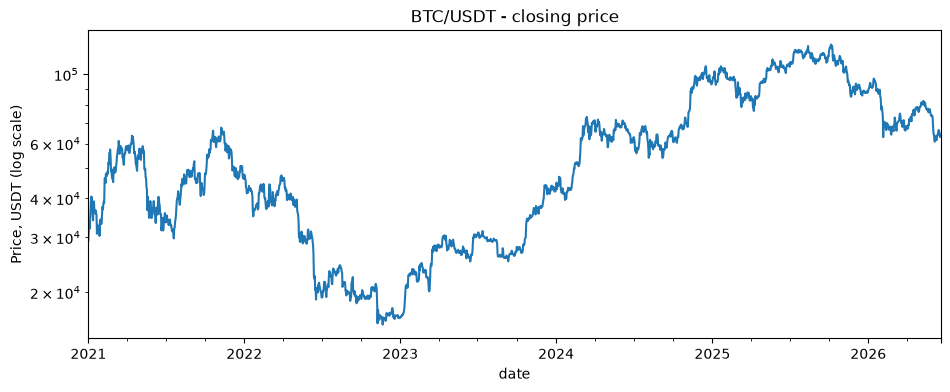

In [3]:
btc["close"].plot(figsize=(11, 4), title="BTC/USDT - closing price", logy=True)
plt.ylabel("Price, USDT (log scale)")
plt.show()

## 2. Baseline strategy: moving-average crossover

**Idea.** We compute two moving averages of price: a "fast" one (short window, e.g. 20 days) and a "slow" one (long window, e.g. 50 days).
- fast **above** slow -> uptrend -> **hold long** (position = 1);
- fast **below** slow -> **move to cash** (position = 0).

The rule is simple and has no training - which makes it ideal as a reference point.

**Honest testing.** A signal on day *t* is executed only on the next day *t+1* - otherwise we would be "peeking into the future." This is baked into the engine (`shift(1)`). A 0.1% fee is deducted on every trade.

In [4]:
strategy = MovingAverageCross(fast=20, slow=50)
result = run_backtest(btc, strategy, cost=0.001)

print(f"Strategy: {strategy.name}\n")
for name, value in result.metrics.items():
    print(f"{name:>14}: {value:.3f}")

Strategy: MA(20,50)

  total_return: 0.116
          CAGR: 0.020
        sharpe: 0.239
       sortino: 0.351
  max_drawdown: -0.587


### What the metrics mean
- **total_return** - total return over the period (ROI). `0.5` = +50%.
- **CAGR** - compound annual growth rate.
- **sharpe** - return per unit of risk; > 1 is considered good.
- **max_drawdown** - the deepest peak-to-trough decline. `-0.4` = lost 40%.

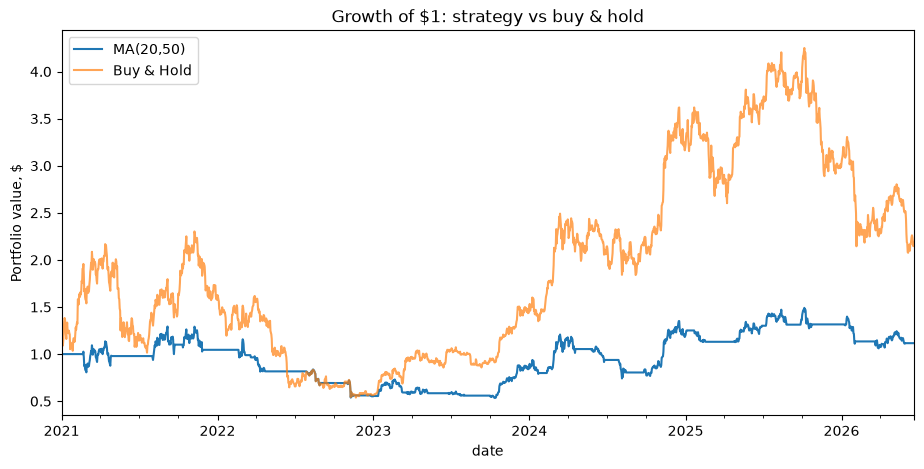

In [5]:
buy_hold = (1 + btc["close"].pct_change().fillna(0)).cumprod()

ax = result.equity_curve.plot(figsize=(11, 5), label=strategy.name)
buy_hold.plot(ax=ax, label="Buy & Hold", alpha=0.7)
ax.set_title("Growth of $1: strategy vs buy & hold")
ax.set_ylabel("Portfolio value, $")
ax.legend()
plt.show()

## 3. Comparing parameters
Different moving-average windows versus simple buy & hold.

In [6]:
configs = [(10, 30), (20, 50), (50, 200)]
rows = []
for fast, slow in configs:
    r = run_backtest(btc, MovingAverageCross(fast, slow))
    rows.append({"strategy": f"MA({fast},{slow})", **r.metrics})

bh_returns = btc["close"].pct_change().fillna(0)
bh_equity = (1 + bh_returns).cumprod()
rows.append({
    "strategy": "Buy & Hold",
    "total_return": M.total_return(bh_returns),
    "CAGR": M.cagr(bh_returns),
    "sharpe": M.sharpe_ratio(bh_returns),
    "max_drawdown": M.max_drawdown(bh_equity),
})

pd.DataFrame(rows).set_index("strategy").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
strategy,,,,,
"MA(10,30)",0.305,0.050,0.318,0.469,-0.636
"MA(20,50)",0.116,0.020,0.239,0.351,-0.587
"MA(50,200)",0.662,0.097,0.440,0.661,-0.448
Buy & Hold,1.178,0.153,0.535,NaN,-0.766


## 4. Conclusion for Level 1

On **a single asset with strong multi-year growth**, a trend-following strategy loses to buy & hold on return and Sharpe - because while in cash it misses sharp rebounds. But it noticeably **reduces drawdown**. This is not a failure: the goal of a hedge fund is *risk-adjusted* return and diversification, not "beating a single coin." Next we relax the rigid rule and move to a learning agent.

# Level 2. AI agents on a single pair (BTC/USDT)

Now we replace the 20/50 rule with a **learning agent**. It searches for patterns in the data itself and predicts the direction of price. We answer the key questions of the assignment:

- **Which features?** momentum (returns over 1/5/10 days), volatility, distance to the moving averages, RSI, change in volume.
- **Target variable?** whether the price will rise tomorrow (1) or not (0).
- **How do we train and test?** a chronological split: train on the past, validate on the future (out-of-sample). Shuffling is not allowed - this is a time series.

## 1. Honest split: train and test
The first 70% of history is for training, the last 30% for validation. The model **never** sees the test period during training.

In [7]:
split_idx = int(len(btc) * 0.7)
split_date = btc.index[split_idx]
train_prices = btc.iloc[:split_idx]

print(f"Train: {train_prices.index.min().date()} → {train_prices.index.max().date()} ({len(train_prices)} days)")
print(f"Test (OOS): {split_date.date()} → {btc.index.max().date()} ({len(btc) - split_idx} days)")

Train: 2021-01-01 → 2024-10-28 (1397 days)
Test (OOS): 2024-10-29 → 2026-06-20 (600 days)


## 2. Features and target variable
Let's look at the feature table the agent uses as input.

In [8]:
from chf.features import make_features, make_target

X = make_features(btc)
y = make_target(btc)
X.tail()

,ret_1,ret_5,ret_10,vol_10,vol_30,mom_20,mom_50,rsi_14,vol_change_5
date,,,,,,,,,
2026-06-16 00:00:00+00:00,-0.009856,0.032204,0.078680,0.019579,0.021922,-0.006317,-0.106351,47.451519,-0.177142
2026-06-17 00:00:00+00:00,-0.017748,0.014618,0.018591,0.017366,0.022040,-0.017181,-0.119376,51.966967,0.161712
2026-06-18 00:00:00+00:00,-0.024049,-0.023271,-0.002029,0.019197,0.022282,-0.033081,-0.137535,47.726123,0.700235
2026-06-19 00:00:00+00:00,0.009306,-0.033501,0.029385,0.017791,0.022281,-0.016271,-0.126444,60.069591,0.079102
2026-06-20 00:00:00+00:00,0.005541,-0.036677,0.038774,0.017648,0.022350,-0.003276,-0.118128,61.898807,-0.553081


## 3. ML agent: random forest
We use a **random forest** (an ensemble of shallow trees) - it is robust to noise and needs no scaling. The trees are shallow and the leaves large - a guard against overfitting on a noisy market.

The agent trains **only on train**, and then generates signals over the full history (the features need a "warm-up"). We evaluate it **only on the test segment**.

In [9]:
from chf.strategies.ml import MLAgent

ml = MLAgent(train_prices)          # train only on the training set
result_ml = run_backtest(btc, ml)   # signals over the full history

def metrics_on(returns):
    """Metrics for a slice of returns (the equity curve starts at 1.0)."""
    equity = (1 + returns).cumprod()
    return M.summary(returns, equity)

print("ML agent trained. Features:", ml.feature_names)

ML agent trained. Features: ['ret_1', 'ret_5', 'ret_10', 'vol_10', 'vol_30', 'mom_20', 'mom_50', 'rsi_14', 'vol_change_5']


## 4. Comparison on the test set (out-of-sample)
All three approaches on the same **test** segment, fairly.

In [10]:
ma = MovingAverageCross(50, 200)
result_ma = run_backtest(btc, ma)
test_asset_ret = btc.loc[split_date:, "close"].pct_change().fillna(0)

rows = [
    {"strategy": ml.name,      **metrics_on(result_ml.returns.loc[split_date:])},
    {"strategy": ma.name,      **metrics_on(result_ma.returns.loc[split_date:])},
    {"strategy": "Buy & Hold", **metrics_on(test_asset_ret)},
]
pd.DataFrame(rows).set_index("strategy").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
strategy,,,,,
ML (RandomForest),-0.226,-0.144,-0.283,-0.401,-0.433
"MA(50,200)",-0.049,-0.030,0.072,0.105,-0.373
Buy & Hold,-0.122,-0.076,0.053,0.077,-0.512


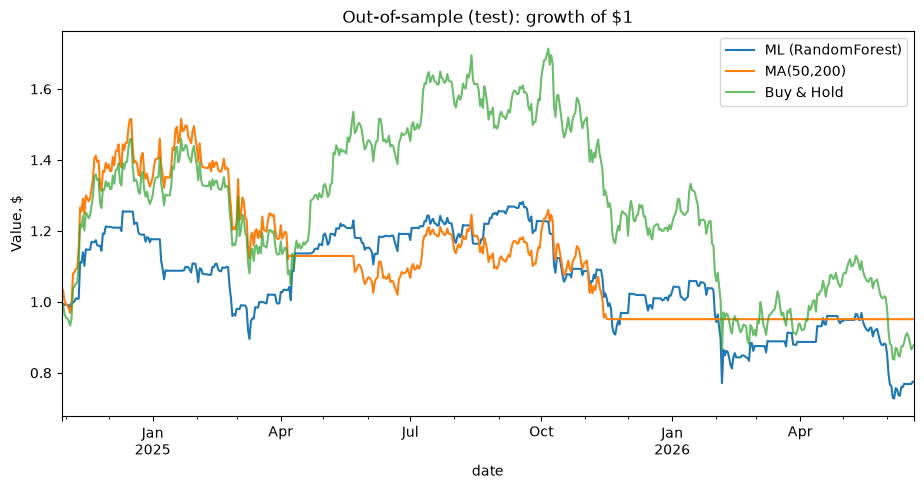

In [11]:
curve_ml = (1 + result_ml.returns.loc[split_date:]).cumprod()
curve_ma = (1 + result_ma.returns.loc[split_date:]).cumprod()
curve_bh = (1 + test_asset_ret).cumprod()

ax = curve_ml.plot(figsize=(11, 5), label=ml.name)
curve_ma.plot(ax=ax, label=ma.name)
curve_bh.plot(ax=ax, label="Buy & Hold", alpha=0.7)
ax.set_title("Out-of-sample (test): growth of $1")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## 5. Sanity check: is this just luck?
Two tests: (a) directional prediction accuracy versus "guessing the majority"; (b) comparing our agent's Sharpe against hundreds of **random** strategies.

In [12]:
from sklearn.metrics import accuracy_score

X_test = make_features(btc).loc[split_date:].dropna()
y_test = make_target(btc).loc[X_test.index]
pred = ml.model.predict(X_test[ml.feature_names])

acc = accuracy_score(y_test, pred)
majority = max(y_test.mean(), 1 - y_test.mean())
print(f"Directional accuracy (test): {acc:.1%}")
print(f"Majority-class guess:           {majority:.1%}")

Directional accuracy (test): 49.0%
Majority-class guess:           50.7%


In [13]:
import numpy as np

rng = np.random.default_rng(42)
n_random = 300
random_sharpes = []
for _ in range(n_random):
    pos = pd.Series(rng.integers(0, 2, len(test_asset_ret)), index=test_asset_ret.index)
    pos = pos.shift(1).fillna(0)
    random_sharpes.append(M.sharpe_ratio(pos * test_asset_ret))
random_sharpes = np.array(random_sharpes)

ml_sharpe = metrics_on(result_ml.returns.loc[split_date:])["sharpe"]
better_than = (random_sharpes < ml_sharpe).mean() * 100
print(f"Sharpe of the ML agent (test): {ml_sharpe:.3f}")
print(f"Better than {better_than:.0f}% of {n_random} random strategies")

Sharpe of the ML agent (test): -0.283
Better than 28% of 300 random strategies


## 6. Conclusions for Level 2

**On accuracy.** Predicting the daily direction of price is very hard - around 50% accuracy is normal even for good models. But this does not make the agent useless: the value is not in the share of correct guesses, but in being in the market during big moves and out of it during declines. So we judge by **return and risk**, not by accuracy.

**How often to retrain?** In production a model goes stale: the market changes. The right approach is to retrain periodically on a rolling window (e.g. monthly/quarterly). The next methodological improvement is *walk-forward* (many sequential retrainings instead of a single split).

**Why these metrics?** A hedge fund lives on **risk-adjusted** return and the ability to survive a drawdown. So Sharpe and max_drawdown matter more than "raw" return.

---
**Next:** we add econometrics (GARCH for estimating volatility and managing position size), and then move to **Level 3** - a portfolio of several coins.

In [14]:
# === Long/Short MA strategy with a funding-cost penalty for shorts ===
from chf.strategies.moving_average_ls import MovingAverageCrossLS

# 1. Run the long/short strategy through the SAME honest backtester
ma_ls = MovingAverageCrossLS(50, 200)
result_ls = run_backtest(btc, ma_ls)

# 2. Funding penalty: a perp short pays funding (~ here a conservative
#    flat 11%/year). We charge it only on days the position is SHORT.
#    This is a deliberately pessimistic estimate (no historical funding
#    data in the dataset), so the strategy is judged harshly, not flattered.
FUNDING_ANNUAL = 0.11
funding_daily  = FUNDING_ANNUAL / 365

positions_ls = ma_ls.generate_signals(btc).shift(1).fillna(0.0)
is_short     = (positions_ls < 0).astype(float)
funding_cost = is_short * funding_daily          # paid on short days
returns_ls_net = result_ls.returns - funding_cost

# 3. Compare on the test set: long/short (net of funding) vs the long-only
#    baseline vs Buy & Hold. Same test window as before.
rows = [
    {"strategy": "MA-LS(50,200) net", **metrics_on(returns_ls_net.loc[split_date:])},
    {"strategy": "MA(50,200) long-only", **metrics_on(result_ma.returns.loc[split_date:])},
    {"strategy": "Buy & Hold", **metrics_on(test_asset_ret)},
]
pd.DataFrame(rows).set_index("strategy").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
strategy,,,,,
"MA-LS(50,200) net",-0.221,-0.141,-0.106,-0.150,-0.602
"MA(50,200) long-only",-0.049,-0.030,0.072,0.105,-0.373
Buy & Hold,-0.122,-0.076,0.053,0.077,-0.512


### Adding shorts: does it help? (No — and that is the point.)

We extend the Level-1 crossover into a **long/short** rule: long on a golden cross, **short on a death cross** (always in the market), and we charge a conservative ~11%/year funding cost on every short day.

| Strategy | Total return | Sharpe | Max drawdown |
|---|---|---|---|
| MA-LS(50,200), net of funding | **−0.221** | **−0.106** | **−0.602** |
| MA(50,200), long-only | −0.049 | 0.072 | −0.373 |
| Buy & Hold | −0.122 | 0.053 | −0.512 |

**The long/short version is worse on every metric** — lower return, negative Sharpe, deeper drawdown. Two reasons:

- **Death cross is a lagging signal.** By the time the 50-day MA crosses below the 200-day, most of the drop has already happened; the short is opened near the bottom and is repeatedly caught by crypto's sharp upward reversals.
- **Shorts are not free.** Funding is paid every day a short is held, and long↔short flips double the turnover, so trading costs bite harder.

This is the **same lesson** as Levels 2 and 3, from a third angle: added complexity (shorting) did not pay. The disciplined long-only baseline — and especially simple diversification — remained more robust. A real fund would prefer reducing exposure (going flat) in downtrends over actively shorting a lagging signal.

# Level 3. A portfolio of several coins

The lesson of Levels 1-2: predicting a single coin is hard. The real edge of a hedge fund is **diversification**: spreading capital across assets so that, for the same return, risk is lower.

Key concepts (Markowitz theory):

- **Optimal portfolio** - the set of weights with the best return/risk ratio.
- **Efficient frontier** - the portfolios that give maximum return for a given level of risk.
- **Max Sharpe** - the best risk-adjusted portfolio; **Min Variance** - the "calmest" one.

## 1. The coins and their returns

We take 6 popular coins and compute their daily returns.

In [15]:
from chf.data.loader import load_close_prices
from chf.services import portfolio as port

coins = ["BTC/USDT", "ETH/USDT", "SOL/USDT", "BNB/USDT", "ZEC/USDT", "DOGE/USDT"]
prices = load_close_prices(coins)
returns = prices.pct_change().dropna()
returns.tail()

,BTC/USDT,ETH/USDT,SOL/USDT,BNB/USDT,ZEC/USDT,DOGE/USDT
date,,,,,,
2026-06-16 00:00:00+00:00,-0.009856,-0.001748,-0.006218,-0.020927,-0.026201,-0.011005
2026-06-17 00:00:00+00:00,-0.017748,-0.023642,-0.019995,-0.005472,-0.055158,-0.014225
2026-06-18 00:00:00+00:00,-0.024049,-0.022558,-0.032477,-0.038479,-0.044821,-0.028046
2026-06-19 00:00:00+00:00,0.009306,0.000047,0.000430,0.005082,0.045981,0.000599
2026-06-20 00:00:00+00:00,0.005541,0.009292,0.027674,0.007550,-0.024434,-0.004427


### Correlations
Crypto coins are strongly linked (they rise and fall together), but **not 100%** - it is precisely this incomplete linkage that makes diversification useful.

In [16]:
returns.corr().round(2)

,BTC/USDT,ETH/USDT,SOL/USDT,BNB/USDT,ZEC/USDT,DOGE/USDT
BTC/USDT,1.00,0.81,0.61,0.64,0.55,0.38
ETH/USDT,0.81,1.00,0.66,0.65,0.56,0.35
SOL/USDT,0.61,0.66,1.00,0.57,0.46,0.26
BNB/USDT,0.64,0.65,0.57,1.00,0.47,0.24
ZEC/USDT,0.55,0.56,0.46,0.47,1.00,0.26
DOGE/USDT,0.38,0.35,0.26,0.24,0.26,1.00


## 2. Honest split
We compute the portfolio weights on **train** and validate on the held-out **test**. Optimizing and validating on the same data is not allowed: the "optimal" portfolio always looks great on the past.

In [17]:
split_idx = int(len(returns) * 0.7)
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]
mean, cov = port.annualized_stats(train_returns)

print(f"Weight estimation (train): {train_returns.index.min().date()} → {train_returns.index.max().date()}")
print(f"Validation (test):      {test_returns.index.min().date()} → {test_returns.index.max().date()}")

Weight estimation (train): 2021-01-02 → 2024-10-29
Validation (test):      2024-10-30 → 2026-06-20


## 3. Optimal portfolios
We compute three sets of weights: maximum Sharpe, minimum risk, and equal weights (a simple benchmark).

In [18]:
w_ms = port.max_sharpe(mean, cov)
w_mv = port.min_variance(mean, cov)
w_eq = pd.Series(1 / len(coins), index=mean.index)

weights = pd.DataFrame({"Max Sharpe": w_ms, "Min Variance": w_mv, "Equal weight": w_eq})
weights.round(3)

,Max Sharpe,Min Variance,Equal weight
BTC/USDT,0.000,0.952,0.167
ETH/USDT,0.000,0.000,0.167
SOL/USDT,0.586,0.000,0.167
BNB/USDT,0.265,0.048,0.167
ZEC/USDT,0.000,0.000,0.167
DOGE/USDT,0.149,0.000,0.167


In [19]:
perf = {}
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    r, v, s = port.portfolio_performance(w, mean, cov)
    perf[name] = {"return": r, "volatility": v, "sharpe": s}
pd.DataFrame(perf).T.round(3)

,return,volatility,sharpe
Max Sharpe,1.782,1.016,1.755
Min Variance,0.466,0.624,0.746
Equal weight,1.158,0.854,1.355


### Efficient frontier
The grey cloud is thousands of random portfolios. The stars are our optimal ones. The diamonds are individual coins. You can see the portfolios sit **further left** (lower risk) than the individual coins - that is diversification.

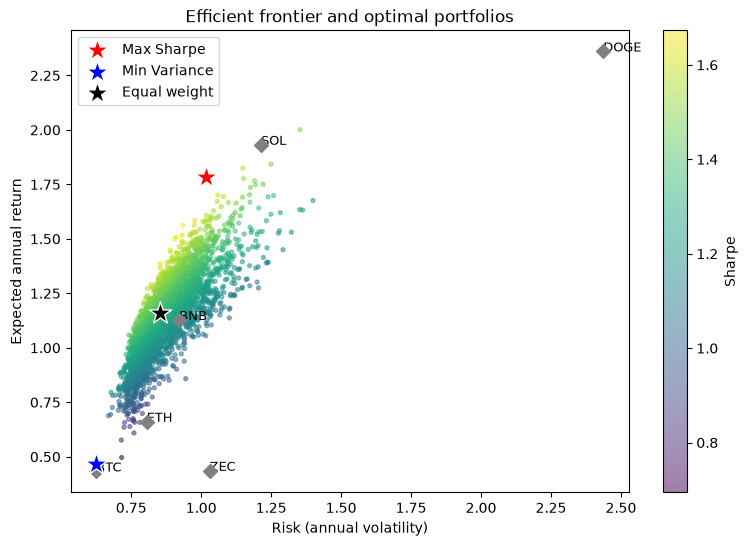

In [20]:
import numpy as np

rr, vv, ss = port.random_portfolios(3000, mean, cov)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(vv, rr, c=ss, cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Sharpe")

for label, w, color in [("Max Sharpe", w_ms, "red"), ("Min Variance", w_mv, "blue"), ("Equal weight", w_eq, "black")]:
    r, v, s = port.portfolio_performance(w, mean, cov)
    ax.scatter(v, r, c=color, marker="*", s=280, edgecolors="white", label=label, zorder=5)

for coin in mean.index:
    v = float(np.sqrt(cov.loc[coin, coin]))
    ax.scatter(v, mean[coin], marker="D", s=50, color="grey", zorder=4)
    ax.annotate(coin.split("/")[0], (v, mean[coin]), fontsize=9)

ax.set_xlabel("Risk (annual volatility)")
ax.set_ylabel("Expected annual return")
ax.set_title("Efficient frontier and optimal portfolios")
ax.legend()
plt.show()

## 4. Honest validation on the test set
We take the weights computed on train, **freeze** them, and look at how they would have performed on the test set - against simply "holding only BTC".

In [21]:
results = {}
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    results[name] = metrics_on(port.portfolio_returns(w, test_returns))

results["BTC only"] = metrics_on(test_returns["BTC/USDT"])
pd.DataFrame(results).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Max Sharpe,-0.438,-0.296,-0.165,-0.233,-0.679
Min Variance,-0.113,-0.070,0.064,0.092,-0.512
Equal weight,0.337,0.194,0.597,0.869,-0.494
BTC only,-0.122,-0.076,0.053,0.077,-0.512


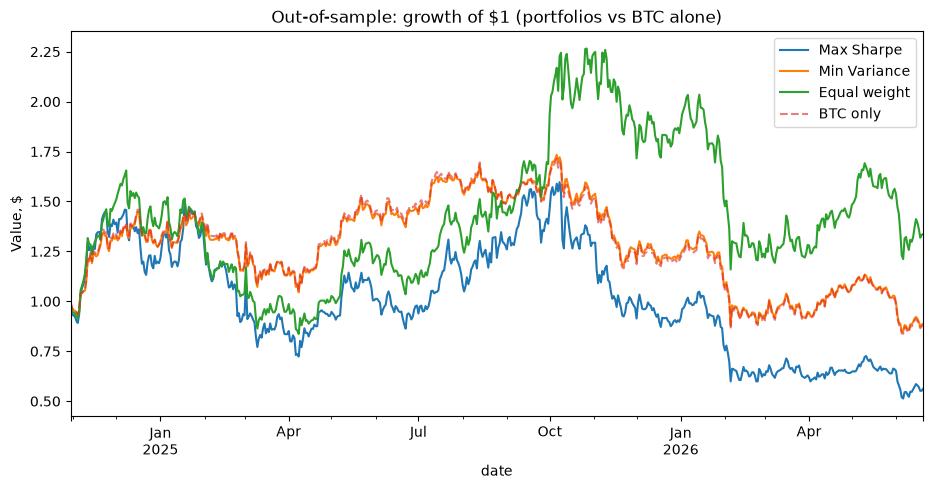

In [22]:
ax = None
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    curve = (1 + port.portfolio_returns(w, test_returns)).cumprod()
    ax = curve.plot(figsize=(11, 5), label=name, ax=ax)

btc_curve = (1 + test_returns["BTC/USDT"]).cumprod()
btc_curve.plot(ax=ax, label="BTC only", alpha=0.6, linestyle="--")
ax.set_title("Out-of-sample: growth of $1 (portfolios vs BTC alone)")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## 5. Conclusions for Level 3

**What the optimal portfolio is.** It is the weights on the upper edge of the "cloud" (the efficient frontier): maximum return for a given level of risk. Diversification works because the coins are not perfectly correlated - a mix reduces risk more than it gives up in return.

**On honesty again.** Max Sharpe is computed from past average returns, which are very noisy - so such a portfolio is often "fitted" to past winners and holds up worse on the test set. Min Variance and equal weights are usually more robust. This is the same idea as in Level 2: overfitting is punished in portfolios too.

**Metrics.** Annual return, volatility, Sharpe and drawdown - the same things we use to measure a risk-adjusted result.

---
**Next - Level 4:** weights should not be eternal. The market changes, so the portfolio must be **rebalanced** periodically by a rule.

## 6. Brief check: the optimal portfolio on the last 12 months

The assignment asks specifically for static portfolio management on the **last 12 months**. The analysis above deliberately used the full multi-year history, because:

- 12 months of daily data is a very short sample for estimating a 6×6 covariance matrix and average returns — the estimates are dominated by noise;
- the failure of mean–variance optimisation (Max Sharpe) only shows up across a **regime change** (bull → bear), which a single calm 12-month window may not contain.

To satisfy the brief — and to show how much a single window can differ — we repeat the exercise here on the last 12 months, with the same honest train/validate split.

In [23]:
# === Level 3 — brief check: static allocation on the LAST 12 MONTHS ===

# 1. Take only the last 12 months of daily returns
last_date   = returns.index.max()
start_12m   = last_date - pd.DateOffset(months=12)
returns_12m = returns.loc[returns.index >= start_12m]

# 2. Honest split inside the window (estimate weights on train, validate on the tail)
split_12 = int(len(returns_12m) * 0.75)
train_12 = returns_12m.iloc[:split_12]
test_12  = returns_12m.iloc[split_12:]
mean_12, cov_12 = port.annualized_stats(train_12)

print(f"12-month window:    {returns_12m.index.min().date()} -> {returns_12m.index.max().date()}")
print(f"  estimate (train): {train_12.index.min().date()} -> {train_12.index.max().date()}")
print(f"  validate (test):  {test_12.index.min().date()} -> {test_12.index.max().date()}")

# 3. The three portfolios, estimated on the 12-month train window
w_ms_12 = port.max_sharpe(mean_12, cov_12)
w_mv_12 = port.min_variance(mean_12, cov_12)
w_eq_12 = pd.Series(1 / len(coins), index=mean_12.index)

weights_12 = pd.DataFrame({"Max Sharpe": w_ms_12,
                           "Min Variance": w_mv_12,
                           "Equal weight": w_eq_12})
print("\nOptimal weights, estimated on the last 12 months:")
display(weights_12.round(3))

# 4. Out-of-sample check on the held-out tail, vs simply holding BTC
results_12 = {}
for name, w in [("Max Sharpe", w_ms_12), ("Min Variance", w_mv_12), ("Equal weight", w_eq_12)]:
    results_12[name] = metrics_on(port.portfolio_returns(w, test_12))
results_12["BTC only"] = metrics_on(test_12["BTC/USDT"])

print("\nOut-of-sample metrics on the last 12-month window (short -> noisy):")
pd.DataFrame(results_12).T.round(3)

12-month window:    2025-06-20 -> 2026-06-20
  estimate (train): 2025-06-20 -> 2026-03-20
  validate (test):  2026-03-21 -> 2026-06-20

Optimal weights, estimated on the last 12 months:


,Max Sharpe,Min Variance,Equal weight
BTC/USDT,0.0,0.967,0.167
ETH/USDT,0.0,0.000,0.167
SOL/USDT,0.0,0.000,0.167
BNB/USDT,0.0,0.033,0.167
ZEC/USDT,1.0,0.000,0.167
DOGE/USDT,0.0,0.000,0.167



Out-of-sample metrics on the last 12-month window (short -> noisy):


,total_return,CAGR,sharpe,sortino,max_drawdown
Max Sharpe,0.983,14.131,2.573,4.366,-0.462
Min Variance,-0.093,-0.322,-0.830,-1.134,-0.255
Equal weight,0.022,0.090,0.424,0.628,-0.284
BTC only,-0.094,-0.323,-0.830,-1.137,-0.259


**Reading this.** The validation tail here is only ~3 months, so these numbers are noisy and should not be over-interpreted — that is the point. Depending on which 12 months you pick, the "optimal" Max-Sharpe portfolio can look great or terrible. The multi-year analysis above is more reliable because it spans several regimes — the same lesson as Level 2: on short, noisy samples, simple and robust (equal weight / min-variance) beats fitted optimisation.

**How this would be applied in real trading.** Re-estimate weights on a rolling window, cap the single-asset weight, and prefer the more robust allocations (equal weight or min-variance) over raw Max-Sharpe — which Level 4 makes concrete by rebalancing on a rule.

# Level 4. Dynamic rebalancing

In Level 3 the weights were computed once and frozen. But the market changes - coins that were "calm" yesterday can be turbulent today. The solution: periodically **recompute the weights on fresh data**.

Types of rebalancing:
- **time-based** - every N days (the one we implement);
- **threshold-based** - when a coin's share drifts from its target by more than X%;
- **signal-based** - driven by agents or risk metrics (a bridge to Level 5).

We do it walk-forward: every N days we recompute the weights **using only the past window** (no peeking ahead). A fee is charged on every trade - so rebalancing too often can "eat" the profit.

## 1. Static versus dynamic
Let's compare the **frozen** Min Variance from Level 3 with a **dynamic** one - where the covariance is recomputed every 30 days from the last 180 days.

In [24]:
from chf.services.rebalancing import rebalance_backtest, equal_weights, min_var_weights

dyn_mv_net, dyn_mv_w, n_reb = rebalance_backtest(returns, min_var_weights, lookback=180, rebalance_every=30)
dyn_eq_net, _, _ = rebalance_backtest(returns, equal_weights, lookback=180, rebalance_every=30)

print(f"Dynamic Min Variance: {n_reb} rebalances over the whole period")

Dynamic Min Variance: 61 rebalances over the whole period


In [25]:
results4 = {
    "Min Var (static)":  metrics_on(port.portfolio_returns(w_mv, test_returns)),
    "Min Var (dynamic)": metrics_on(dyn_mv_net.loc[split_date:]),
    "Equal weight":       metrics_on(dyn_eq_net.loc[split_date:]),
    "BTC only":         metrics_on(test_returns["BTC/USDT"]),
}
pd.DataFrame(results4).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Min Var (static),-0.113,-0.070,0.064,0.092,-0.512
Min Var (dynamic),0.147,0.087,0.411,0.586,-0.500
Equal weight,0.376,0.214,0.624,0.908,-0.494
BTC only,-0.122,-0.076,0.053,0.077,-0.512


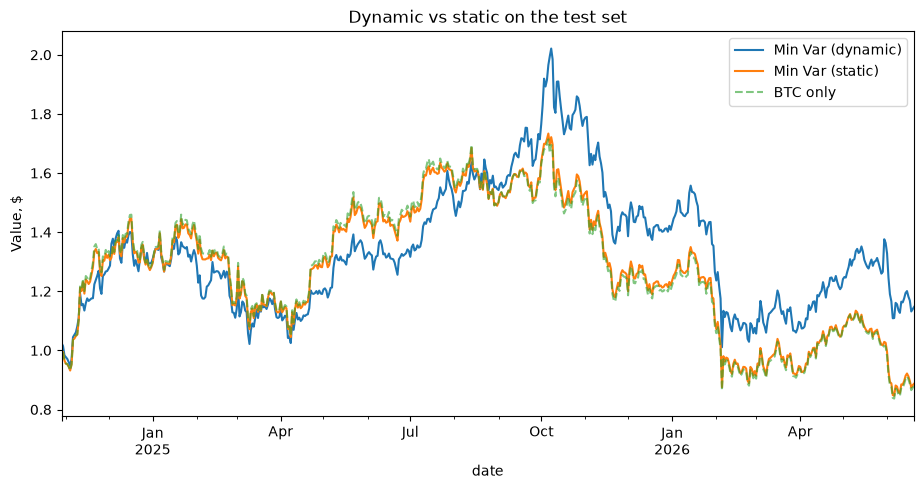

In [26]:
ax = (1 + dyn_mv_net.loc[split_date:]).cumprod().plot(figsize=(11, 5), label="Min Var (dynamic)")
(1 + port.portfolio_returns(w_mv, test_returns)).cumprod().plot(ax=ax, label="Min Var (static)")
(1 + test_returns["BTC/USDT"]).cumprod().plot(ax=ax, label="BTC only", alpha=0.6, linestyle="--")
ax.set_title("Dynamic vs static on the test set")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## 2. How often to rebalance? Adaptivity versus costs
More frequent rebalancing = faster adaptation, but more trades and fees. We look at the result **after costs** and at the number of rebalances.

In [27]:
freq_rows = []
for every in [7, 30, 90, 180]:
    net, _, n = rebalance_backtest(returns, min_var_weights, lookback=180, rebalance_every=every)
    freq_rows.append({"rebalance_every_days": every, "n_rebalances": n, **metrics_on(net.loc[split_date:])})
pd.DataFrame(freq_rows).set_index("rebalance_every_days").round(3)

,n_rebalances,total_return,CAGR,sharpe,sortino,max_drawdown
rebalance_every_days,,,,,,
7,260,0.115,0.068,0.372,0.531,-0.491
30,61,0.147,0.087,0.411,0.586,-0.500
90,21,0.001,0.001,0.230,0.325,-0.519
180,11,0.064,0.038,0.312,0.442,-0.521


## 3. Stress test: crises
The dynamic strategy is honest over the whole period (each day uses only the past), so let's test it on real crashes: **LUNA/UST** (May 2022), **FTX** (November 2022) and the **10/10 crash** (October 2025 - record liquidations of ~$19bn, amplified by the USDe depeg on Binance).

Important: the 10/10 crash falls inside the **test** period - an honest out-of-sample stress. The data is daily, so the table reflects close-to-close moves, not the intraday "wicks" (in the moment the drop was sharper). We look at how much each approach lost over the crisis window.

In [28]:
crises = {
    "LUNA/UST (May 2022)":   ("2022-05-07", "2022-05-31"),
    "FTX (Nov 2022)":        ("2022-11-01", "2022-11-30"),
    "10/10 crash (Oct 2025)": ("2025-10-01", "2025-10-31"),
}
strategies = {
    "Min Var (dynamic)":      dyn_mv_net,
    "Equal weight (dynamic)": dyn_eq_net,
    "BTC only":              returns["BTC/USDT"],
}

rows = []
for cname, (start, end) in crises.items():
    row = {"crisis": cname}
    for sname, r in strategies.items():
        window = r.loc[start:end]
        row[sname] = (1 + window).prod() - 1   # return over the crisis window
    rows.append(row)

pd.DataFrame(rows).set_index("crisis").round(3)

,Min Var (dynamic),Equal weight (dynamic),BTC only
crisis,,,
LUNA/UST (May 2022),-0.121,-0.261,-0.117
FTX (Nov 2022),-0.133,-0.222,-0.162
10/10 crash (Oct 2025),0.038,0.321,-0.039


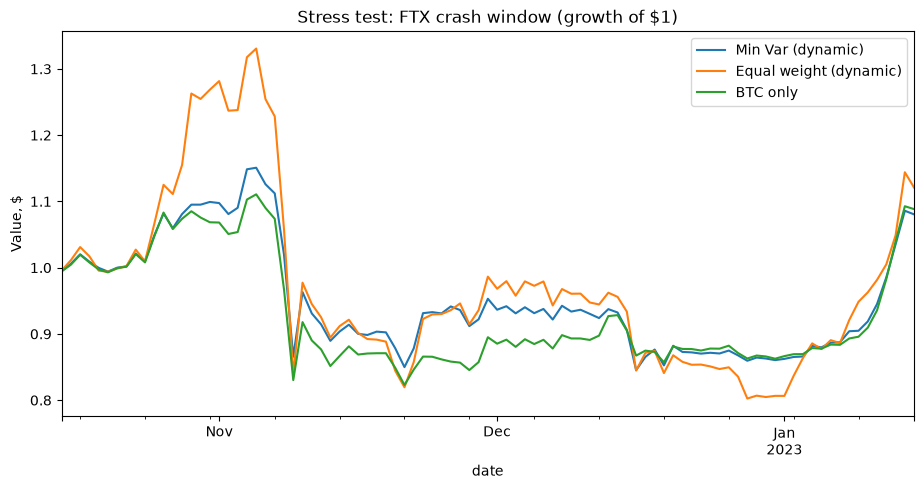

In [29]:
start, end = "2022-10-15", "2023-01-15"
ax = None
for name, r in [("Min Var (dynamic)", dyn_mv_net), ("Equal weight (dynamic)", dyn_eq_net), ("BTC only", returns["BTC/USDT"])]:
    ax = (1 + r.loc[start:end]).cumprod().plot(figsize=(11, 5), label=name, ax=ax)
ax.set_title("Stress test: FTX crash window (growth of $1)")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

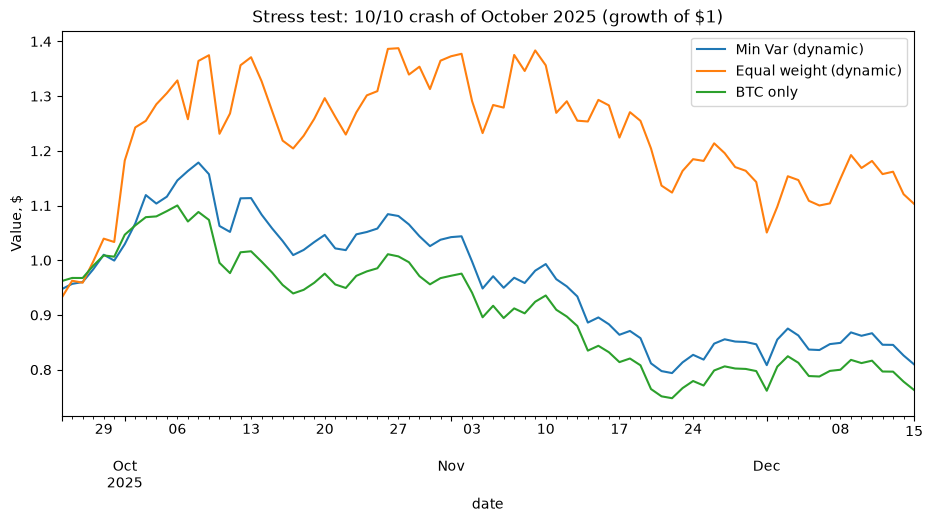

In [30]:
start, end = "2025-09-25", "2025-12-15"
ax = None
for name, r in [("Min Var (dynamic)", dyn_mv_net), ("Equal weight (dynamic)", dyn_eq_net), ("BTC only", returns["BTC/USDT"])]:
    ax = (1 + r.loc[start:end]).cumprod().plot(figsize=(11, 5), label=name, ax=ax)
ax.set_title("Stress test: 10/10 crash of October 2025 (growth of $1)")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## 4. Conclusions for Level 4

**Why go dynamic.** Frozen weights go stale: a risk estimate made on old data stops matching the market. Recomputing on a rolling window keeps the portfolio "in shape."

**How to choose the frequency.** It is a trade-off: more frequent is more adaptive, but more expensive (fees and slippage). We choose by **net** (after-cost) out-of-sample Sharpe, while keeping an eye on turnover. It often turns out that a moderate frequency (monthly/quarterly) beats daily - extra trades only burn money.

**Smarter timing.** Threshold rebalancing (only when a share drifts by X%) saves on trades during calm periods. And signal/risk-based rebalancing (moving capital to cash when volatility rises) is already a bridge to the **risk agent**.

---
**Next - Level 5:** we scale to 100+ pairs. Coins are selected **by a rule** (not by hand!), and we add a risk agent and "stop signals".

# Level 5. Scale: 100+ coins

Until now the coins were picked by hand - for a real fund that is not allowed: it is hindsight fitting. Here we work with a universe of 120 coins and **do not pick them manually**.

The main difficulty: coins have different history lengths, so a common period via `dropna` won't do. The solution is **point-in-time** selection (per date): take only the coins that already existed at that moment and had traded long enough. This eliminates both peeking into the future and survivorship bias.

The Level 5 strategy:
- **Rule-based selection:** from the "mature" coins, take the top 15 by 90-day momentum;
- **weights:** equal (more reliable than optimization - the Level 3 conclusion);
- **risk agent (stop signal):** if the market is in a downtrend regime (BTC below its 100-day average) - move to cash; direct protection against systemic crashes like 10/10;
- **rebalance** every 30 days (the Level 4 optimum).

In [31]:
from chf.services.universe import load_universe_prices, universe_backtest

uni = load_universe_prices()
hist = uni.notna().sum()
print(f"Coins in the universe: {uni.shape[1]}")
print(f"History per coin: median {int(hist.median())} days, min {int(hist.min())}, max {int(hist.max())}")

Coins in the universe: 120
History per coin: median 921 days, min 3, max 1997


## 1. Backtest: with and without the risk agent
Let's compare the strategy with the "stop signal" and without it - and both against simply "holding BTC".

In [32]:
net_risk,   W_risk,   info_risk   = universe_backtest(uni, use_risk_agent=True)
net_norisk, W_norisk, info_norisk = universe_backtest(uni, use_risk_agent=False)

print(f"With risk agent: on average we hold {info_risk['avg_holdings']:.0f} coins, "
      f"in cash for {info_risk['pct_in_cash']:.0%} of {info_risk['n_rebalances']} rebalances")

u_results = {
    "Top-15 momentum + risk agent": metrics_on(net_risk.loc[split_date:]),
    "Top-15 momentum (no agent)": metrics_on(net_norisk.loc[split_date:]),
    "BTC only":                   metrics_on(returns["BTC/USDT"].loc[split_date:]),
}
pd.DataFrame(u_results).T.round(3)

With risk agent: on average we hold 8 coins, in cash for 49% of 61 rebalances


,total_return,CAGR,sharpe,sortino,max_drawdown
Top-15 momentum + risk agent,-0.535,-0.372,-0.439,-0.592,-0.751
Top-15 momentum (no agent),-0.622,-0.447,-0.461,-0.624,-0.821
BTC only,-0.087,-0.054,0.106,0.154,-0.512


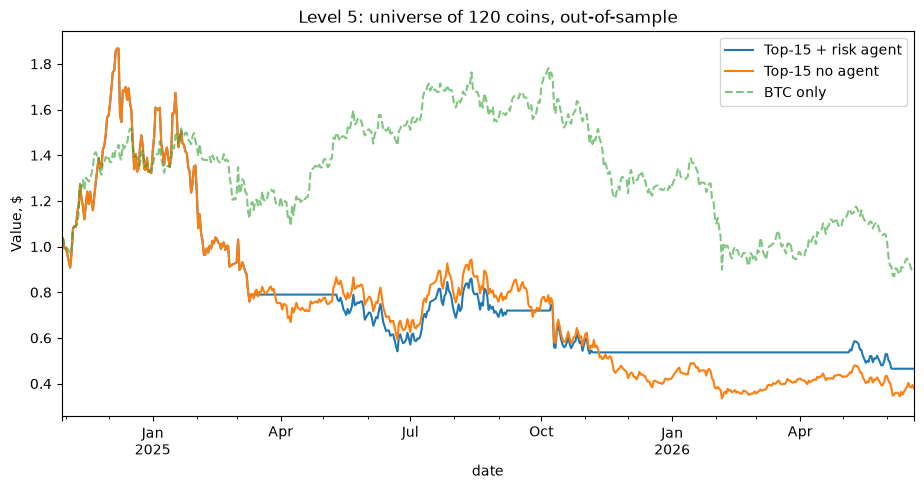

In [33]:
ax = (1 + net_risk.loc[split_date:]).cumprod().plot(figsize=(11, 5), label="Top-15 + risk agent")
(1 + net_norisk.loc[split_date:]).cumprod().plot(ax=ax, label="Top-15 no agent")
(1 + returns["BTC/USDT"].loc[split_date:]).cumprod().plot(ax=ax, label="BTC only", alpha=0.6, linestyle="--")
ax.set_title("Level 5: universe of 120 coins, out-of-sample")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## 2. Did the risk agent help in the crashes?
Let's compare the strategy's drawdown in the FTX and 10/10 windows - with the "stop signal" and without.

In [34]:
u_crises = {
    "FTX (Nov 2022)":        ("2022-11-01", "2022-11-30"),
    "10/10 crash (Oct 2025)": ("2025-10-01", "2025-10-31"),
}
rows = []
for cname, (s, e) in u_crises.items():
    rows.append({
        "crisis":         cname,
        "with risk agent": (1 + net_risk.loc[s:e]).prod() - 1,
        "no agent":     (1 + net_norisk.loc[s:e]).prod() - 1,
        "BTC only":     (1 + returns["BTC/USDT"].loc[s:e]).prod() - 1,
    })
pd.DataFrame(rows).set_index("crisis").round(3)

,with risk agent,no agent,BTC only
crisis,,,
FTX (Nov 2022),0.000,-0.097,-0.162
10/10 crash (Oct 2025),-0.209,-0.179,-0.039


## 3. Conclusions for Level 5

**Scale without fitting.** Coins are selected automatically, by a rule and point-in-time - no manual choice, no survivorship bias. This is an honest way to work with 100+ pairs.

**The risk agent is insurance, not an accelerator.** Moving to cash in a downtrend regime reduces drawdown in crashes at the cost of part of the upside. That is exactly how "stop signals" / fail-safes work: they optimize not for return, but for survival.

**What a production system needs (monitoring and emergency mechanisms):** liquidity and slippage control, position-size limits, an emergency halt on a data or exchange failure (recall 10/10 - the failure of Binance's infrastructure), alerts when the real portfolio drifts from the target.

**Honesty of the result.** If the strategy does not beat BTC out-of-sample - that is a normal outcome. It shows how hard it is to consistently beat the market, and that the system's value is in risk management, not in "return magic." This is the through-line of the whole project: honest validation matters more than pretty numbers.

# Bonus: is the edge in position sizing, not the signal?

Hypothesis: the MA strategy's (Level 1) advantage is not in average return, but in **reduced drawdowns**. And since compounded growth is approximately mu - sigma^2/2, then by cutting volatility and adding position-size management we may beat buy & hold on compounding.

We test it honestly, out-of-sample, after costs. On top of the MA(50,200) signal we apply two classic sizing rules:
- **vol-targeting** - hold a constant target volatility (lever up in calm, down in storms), leverage capped at x2;
- **half Kelly** - bet half the optimum mu/sigma^2 (fractional - because the estimates are noisy and full Kelly over-sizes), capped at x2.

Important to remember: sizing is a **lever on an edge, not a source of edge**. If there is no edge, Kelly tends to zero.

In [35]:
from chf.strategies.moving_average import MovingAverageCross
from chf.services.backtest import run_backtest
from chf.services.sizing import SizedStrategy, vol_target_size, fractional_kelly_size

ma       = MovingAverageCross(50, 200)
ma_vol   = SizedStrategy(ma, vol_target_size,       name="MA + vol-target")
ma_kelly = SizedStrategy(ma, fractional_kelly_size, name="MA + 1/2 Kelly")

sized = {
    "Buy & Hold":        btc["close"].pct_change().fillna(0.0),
    "MA (no sizing)": run_backtest(btc, ma).returns,
    "MA + vol-target":   run_backtest(btc, ma_vol).returns,
    "MA + 1/2 Kelly":      run_backtest(btc, ma_kelly).returns,
}
pd.DataFrame({k: metrics_on(v.loc[split_date:]) for k, v in sized.items()}).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Buy & Hold,-0.087,-0.054,0.106,0.154,-0.512
MA (no sizing),-0.049,-0.030,0.072,0.105,-0.373
MA + vol-target,-0.131,-0.082,0.005,0.007,-0.435
MA + 1/2 Kelly,0.488,0.273,0.732,1.190,-0.392


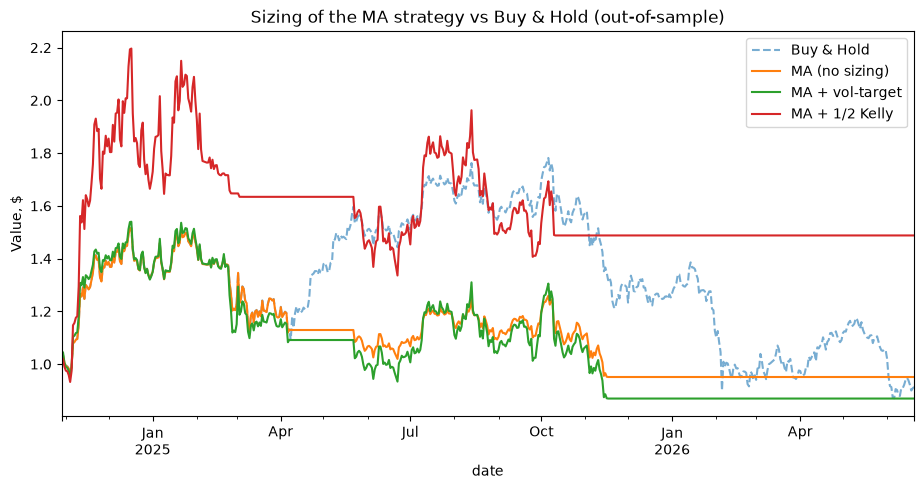

In [36]:
ax = None
for name, r in sized.items():
    style = {"linestyle": "--", "alpha": 0.6} if name == "Buy & Hold" else {}
    ax = (1 + r.loc[split_date:]).cumprod().plot(figsize=(11, 5), label=name, ax=ax, **style)
ax.set_title("Sizing of the MA strategy vs Buy & Hold (out-of-sample)")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

In [37]:
# How much leverage we hold and the turnover (sizing costs)
for name, strat in [("MA + vol-target", ma_vol), ("MA + 1/2 Kelly", ma_kelly)]:
    pos = strat.generate_signals(btc).shift(1).fillna(0.0).loc[split_date:]
    in_pos = pos[pos > 0]
    print(f"{name}: average leverage when in position {in_pos.mean():.2f}, "
          f"share of days in market {len(in_pos) / len(pos):.0%}, turnover {pos.diff().abs().sum():.0f}")

MA + vol-target: average leverage when in position 1.31, share of days in market 56%, turnover 15
MA + 1/2 Kelly: average leverage when in position 1.77, share of days in market 44%, turnover 31


## Conclusion for the bonus

**Sizing is a lever, not magic.** The growth rate at optimal Kelly is approximately Sharpe^2 / 2 - that is, position size amplifies an already-existing edge (quadratically), but creates no profit from a zero edge.

**Where sizing really helps MA:** it turns reduced drawdowns into compounded growth via vol-targeting and safe leverage. If in the table above sizing beat Buy & Hold on Sharpe/drawdown - the hypothesis is confirmed; if not - common reasons are costs from re-sizing (see turnover) or a strongly bullish period where full holding wins.

**Why half Kelly, not full.** The estimates of mu and sigma are noisy -> full Kelly systematically over-sizes; in crypto with fat tails (10/10) that is a road to ruin. Fractional Kelly + a hard leverage cap are mandatory. And remember: portfolio Kelly = inv(Sigma) mu - the same vector as Max Sharpe from Level 3, which overfitted; the same fragility from estimation error.

# Bonus 2: comparison of popular indicators

Let's compare classic signals on BTC, out-of-sample, after costs: **MA**, **MACD**, **RSI** (mean reversion), **Bollinger**, **Donchian breakout** and **momentum**, against **Buy & Hold**.

WARNING **(data-snooping).** One of the six indicators **will inevitably** turn out best on the test - but most often by luck, not by real superiority. So: we use **standard textbook** parameters (not tuned to the test), and the goal is to see that the signals are roughly interchangeable and rarely beat buy & hold consistently. Picking the test winner = overfitting.

In [38]:
from chf.strategies.moving_average import MovingAverageCross
from chf.strategies.indicators import (
    MACDCross, RSIReversion, BollingerReversion, DonchianBreakout, MomentumTS,
)

strategies = [
    MovingAverageCross(50, 200),
    MACDCross(),
    RSIReversion(),
    BollingerReversion(),
    DonchianBreakout(),
    MomentumTS(),
]

comp = {"Buy & Hold": metrics_on(btc["close"].pct_change().fillna(0.0).loc[split_date:])}
for s in strategies:
    comp[s.name] = metrics_on(run_backtest(btc, s).returns.loc[split_date:])

pd.DataFrame(comp).T.round(3).sort_values("sharpe", ascending=False)

,total_return,CAGR,sharpe,sortino,max_drawdown
Моментум(90),0.266,0.154,0.645,0.993,-0.249
Donchian(20) пробой,0.119,0.071,0.384,0.601,-0.346
Buy & Hold,-0.087,-0.054,0.106,0.154,-0.512
"MA(50,200)",-0.049,-0.030,0.072,0.105,-0.373
RSI(14) возврат,-0.073,-0.045,0.033,0.047,-0.259
"MACD(12,26,9)",-0.058,-0.036,0.026,0.039,-0.346
"Bollinger(20,2)",-0.136,-0.085,-0.191,-0.272,-0.383


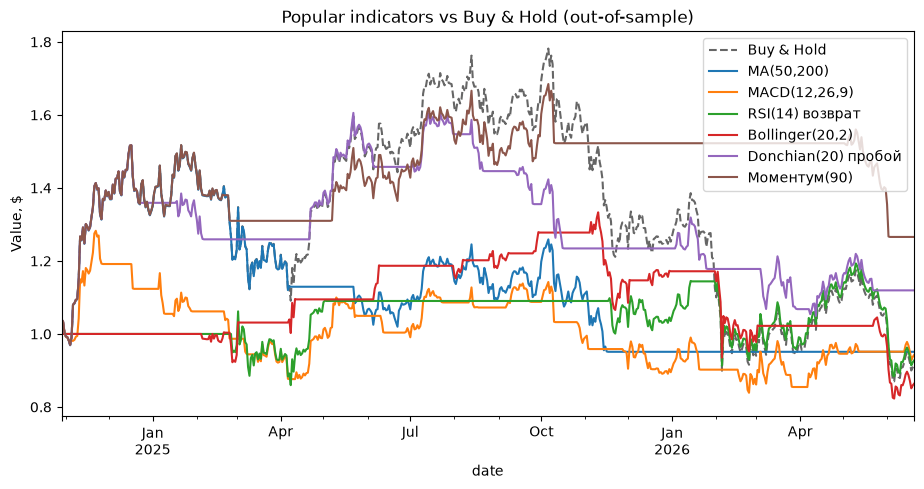

In [39]:
ax = (1 + btc["close"].pct_change().fillna(0.0).loc[split_date:]).cumprod().plot(
    figsize=(11, 5), label="Buy & Hold", linestyle="--", alpha=0.6, color="black")
for s in strategies:
    (1 + run_backtest(btc, s).returns.loc[split_date:]).cumprod().plot(ax=ax, label=s.name)
ax.set_title("Popular indicators vs Buy & Hold (out-of-sample)")
ax.set_ylabel("Value, $")
ax.legend()
plt.show()

## Conclusion for the indicator comparison

**The signals are roughly interchangeable.** The spread between indicators over one period is mostly noise: the best of the six "won" largely by luck, and on a different period/asset the order would change. So **you must not pick the one that is best on the test** - that is data-snooping, the very same overfitting.

**Most do not beat buy & hold consistently.** Like MA in Level 1, the indicators more often deliver not a higher return, but a different shape of risk (less drawdown, less time in the market). Their value is in risk management, not in magical prediction.

**How to choose honestly.** Not by the test result, but by principle: which signal matches your hypothesis about the market (trend vs mean reversion), plus a robustness check on validation and across several assets. And on top of any signal, the decisive factor remains **position size and risk management** - as we saw in the first bonus.

In [40]:
# Time-series cross-validation of the ML agent: fairer than a single split.
import numpy as np

WARMUP = 50  # the longest feature window (mom_50)

def walk_forward_ml(prices, n_splits=5, min_train=400):
    n = len(prices)
    edges = np.linspace(min_train, n, n_splits + 1, dtype=int)
    oos_parts, fold_rows = [], []
    for i in range(n_splits):
        tr_end, te_end = edges[i], edges[i + 1]
        agent = MLAgent(prices.iloc[:tr_end])              # train only on the past
        test_slice = prices.iloc[tr_end - WARMUP:te_end]   # buffer to warm up the features
        oos = run_backtest(test_slice, agent).returns.iloc[WARMUP:]
        oos_parts.append(oos)
        fold_rows.append({"fold": i + 1, **metrics_on(oos)})
    combined = metrics_on(pd.concat(oos_parts))
    print(f"Combined OOS (all 5 folds): Sharpe {combined['sharpe']:.3f}, "
          f"Sortino {combined['sortino']:.3f}, return {combined['total_return']:.1%}")
    return pd.DataFrame(fold_rows).set_index("fold").round(3)

walk_forward_ml(btc)

Combined OOS (all 5 folds): Sharpe 0.030, Sortino 0.042, return -18.9%


,total_return,CAGR,sharpe,sortino,max_drawdown
fold,,,,,
1,-0.157,-0.177,-0.145,-0.201,-0.442
2,0.072,0.083,0.626,1.095,-0.099
3,0.479,0.563,1.668,2.956,-0.188
4,0.157,0.181,0.725,1.130,-0.276
5,-0.476,-0.521,-1.751,-2.248,-0.516


In [41]:
# Sensitivity to costs: fee 0.1% / 0.3% / 0.4%.
cost_rows = []
for c in [0.001, 0.003, 0.004]:
    net, _, _ = universe_backtest(uni, use_risk_agent=True, cost=c)
    cost_rows.append({"cost": f"{c:.1%}", **metrics_on(net.loc[split_date:])})
pd.DataFrame(cost_rows).set_index("cost").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
cost,,,,,
0.1%,-0.535,-0.372,-0.439,-0.592,-0.751
0.3%,-0.547,-0.382,-0.466,-0.628,-0.757
0.4%,-0.553,-0.387,-0.479,-0.646,-0.760


In [42]:
# === Econometric agent: GARCH(1,1) as a volatility-regime filter ===
from arch import arch_model
import numpy as np
from chf.strategies.base import Strategy

class GarchRegimeAgent(Strategy):
    """GARCH(1,1) forecasts volatility: hold the asset in a calm regime,
    move to cash when a 'storm' is forecast. Leak-free: the vol_t forecast depends
    only on past returns."""
    def __init__(self, train_prices, vol_quantile=0.7):
        self.name = "GARCH (vol regime)"
        r = train_prices["close"].pct_change().dropna() * 100   # in % - arch is more stable this way
        self._mu = r.mean()
        res = arch_model(r, vol="GARCH", p=1, q=1, mean="Constant", dist="normal").fit(disp="off")
        self._omega = res.params["omega"]
        self._alpha = res.params["alpha[1]"]
        self._beta = res.params["beta[1]"]
        self._thresh = np.quantile(res.conditional_volatility, vol_quantile)  # "storm" threshold from train

    def generate_signals(self, prices):
        r = prices["close"].pct_change().dropna() * 100
        eps = (r - self._mu).values
        var = np.empty(len(eps))
        var[0] = self._omega / max(1e-9, 1 - self._alpha - self._beta)
        for t in range(1, len(eps)):
            var[t] = self._omega + self._alpha * eps[t-1]**2 + self._beta * var[t-1]
        vol = pd.Series(np.sqrt(var), index=r.index)
        sig = (vol <= self._thresh).astype(float)   # 1 = calm (in position), 0 = storm (cash)
        return sig.reindex(prices.index).fillna(0.0)

garch = GarchRegimeAgent(train_prices)              # train GARCH only on train
result_garch = run_backtest(btc, garch)

# Comparison OOS: econometrics vs ML vs rule vs passive
rows = {
    "GARCH (vol regime)": metrics_on(result_garch.returns.loc[split_date:]),
    "ML (RandomForest)": metrics_on(result_ml.returns.loc[split_date:]),
    "MA (50,200)":       metrics_on(result_ma.returns.loc[split_date:]),
    "Buy & Hold":        metrics_on(test_asset_ret),
}
pd.DataFrame(rows).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
GARCH (vol regime),-0.104,-0.065,0.066,0.095,-0.495
ML (RandomForest),-0.226,-0.144,-0.283,-0.401,-0.433
"MA (50,200)",-0.049,-0.030,0.072,0.105,-0.373
Buy & Hold,-0.122,-0.076,0.053,0.077,-0.512
